# HateLens — Trust & Safety Binary Hate Speech Classifier
### with Human-in-the-Loop Policy Annotation

**Dataset:** Davidson et al. (2017) — Automated Hate Speech Detection and the Problem of Offensive Language  
**Goal:** Mirror the decision-making pipeline of a real Trust & Safety content moderation team.  
**Author:** [Your Name]

---

Every code cell in this notebook includes a plain-English comment above it explaining **WHY** that step exists,  
not just what it does. A recruiter or policy analyst should be able to follow the reasoning without knowing Python.

In [1]:
# WHY: Install and import all dependencies up front so the notebook runs
# top-to-bottom without interruption. Declaring imports in one place also
# makes it trivial to build a requirements.txt later.

import os, sys, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score,
    precision_score, recall_score, accuracy_score, auc
)
from imblearn.over_sampling import SMOTE

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print('WordCloud not installed — skipping WordCloud cells.')

warnings.filterwarnings('ignore')

# Download required NLTK data.
# WHY: NLTK requires its corpora to be downloaded separately from the package.
# We do this once here rather than scattering download() calls throughout.
for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    nltk.download(pkg, quiet=True)

# Add src/ to Python path so we can import our own modules.
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

# Set global plotting style.
# WHY: Consistent styling makes charts easier to read and looks professional
# in a GitHub portfolio. seaborn's 'whitegrid' style reduces chart noise.
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

OUTPUTS_DIR = '../outputs'
DATA_DIR = '../data'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print('All imports successful. Environment ready.')

All imports successful. Environment ready.


---
## Section 2 — Dataset Loading and Label Engineering

In [2]:
# WHY: We load the raw Davidson 2017 dataset to understand its original
# structure before we modify anything. Printing the head, shape, and class
# distribution gives us ground truth about what we're working with.
# Never modify data without first understanding it.
import urllib.request, os
# Download dataset from GitHub if not present locally
DATA_URL = "https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv"
local_path = os.path.join(DATA_DIR, "labeled_data.csv")
if not os.path.exists(local_path):
    print(f"Downloading dataset from {DATA_URL}...")
    urllib.request.urlretrieve(DATA_URL, local_path)
    print("Download complete.")
else:
    print(f"Dataset already present at {local_path}")

df = pd.read_csv(f'{DATA_DIR}/labeled_data.csv')

print('=== First 5 rows ===')
display(df.head())

print(f'\n=== Shape: {df.shape} ===')

print('\n=== Original 3-class distribution ===')
print(df['class'].value_counts())
print('  0 = hate speech | 1 = offensive language | 2 = neither')

Dataset already present at ../data\labeled_data.csv
=== First 5 rows ===


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



=== Shape: (24783, 7) ===

=== Original 3-class distribution ===
class
1    19190
2     4163
0     1430
Name: count, dtype: int64
  0 = hate speech | 1 = offensive language | 2 = neither


In [3]:
# WHY: Content moderation makes a binary decision — remove or keep.
# The policy distinction between 'offensive but not hate' (class=1) and
# 'neutral' (class=2) matters for downstream policy analysis, but for
# this classifier's output we simulate the final removal decision.
# Collapsing to binary also creates a more realistic class imbalance
# that mirrors real-world moderation queues.

# Binary mapping:
#   class == 0 (hate speech)  → label = 1  (flag for removal)
#   class == 1 (offensive)    → label = 0  (keep)
#   class == 2 (neither)      → label = 0  (keep)

df['label'] = df['class'].apply(lambda c: 1 if c == 0 else 0)

print('=== New binary label distribution ===')
label_counts = df['label'].value_counts()
print(label_counts)

majority_count = label_counts[0]
minority_count = label_counts[1]
imbalance_ratio = majority_count / minority_count

print(f'\nClass imbalance ratio (not hate : hate) = {imbalance_ratio:.2f}:1')
print(f'Hate speech is {100 * minority_count / len(df):.1f}% of the dataset.')
print()
print('IMPORTANT: This means a model that predicts "not hate" for EVERY tweet')
print(f'would achieve {100 * majority_count / len(df):.1f}% accuracy. Accuracy is therefore')
print('a deeply misleading metric here — we will use F1, precision, and recall instead.')

=== New binary label distribution ===
label
0    23353
1     1430
Name: count, dtype: int64

Class imbalance ratio (not hate : hate) = 16.33:1
Hate speech is 5.8% of the dataset.

IMPORTANT: This means a model that predicts "not hate" for EVERY tweet
would achieve 94.2% accuracy. Accuracy is therefore
a deeply misleading metric here — we will use F1, precision, and recall instead.


In [4]:
# WHY: We save the binary-labeled dataset so that the training script (train.py)
# can load it directly without re-running the label collapse logic.
# This also gives us a clean artifact to checkpoint before any preprocessing.

binary_path = f'{DATA_DIR}/binary_labeled_data.csv'
df.to_csv(binary_path, index=False)
print(f'Binary-labeled dataset saved to: {binary_path}')

Binary-labeled dataset saved to: ../data/binary_labeled_data.csv


---
## Section 3 — Exploratory Data Analysis (EDA)

**WHY THIS SECTION EXISTS:** Before building any model, a responsible analyst understands the data.  
In a Trust & Safety context, EDA reveals patterns in how hate speech is expressed — which informs  
both the model architecture and the human reviewer's judgment about what to look for.

### 3.1 — Class Distribution

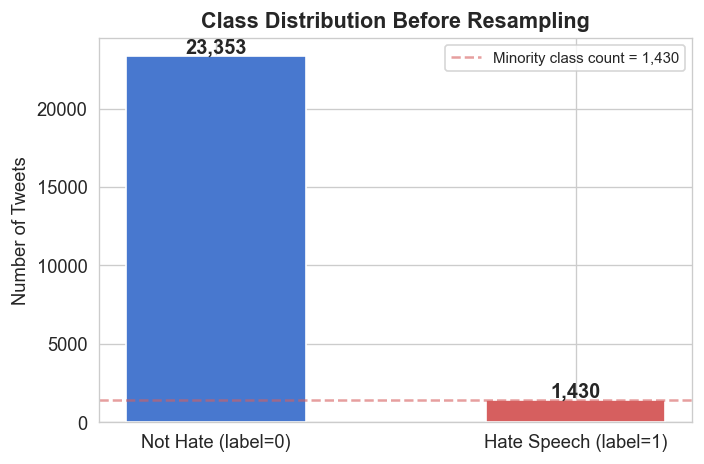

Saved: outputs/class_distribution.png


In [5]:
# WHY: Visualizing the class distribution makes the imbalance undeniable.
# A table of numbers can be overlooked; a chart cannot.
# The dashed reference line at the minority class count anchors the viewer's
# eye to exactly how extreme the imbalance is.

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ['Not Hate (label=0)', 'Hate Speech (label=1)'],
    [label_counts[0], label_counts[1]],
    color=['#4878CF', '#D65F5F'],
    edgecolor='white', width=0.5
)

# Add exact counts on top of bars so a reader doesn't have to estimate.
for bar, count in zip(bars, [label_counts[0], label_counts[1]]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{count:,}',
        ha='center', fontsize=12, fontweight='bold'
    )

# Dashed reference line at the minority count for visual comparison.
ax.axhline(label_counts[1], linestyle='--', color='#D65F5F', alpha=0.6,
           label=f'Minority class count = {label_counts[1]:,}')

ax.set_title('Class Distribution Before Resampling', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Tweets', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{OUTPUTS_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/class_distribution.png')

### 3.2 — Tweet Length Analysis

Avg tweet length — Hate Speech : 84.6 chars
Avg tweet length — Not Hate    : 85.5 chars


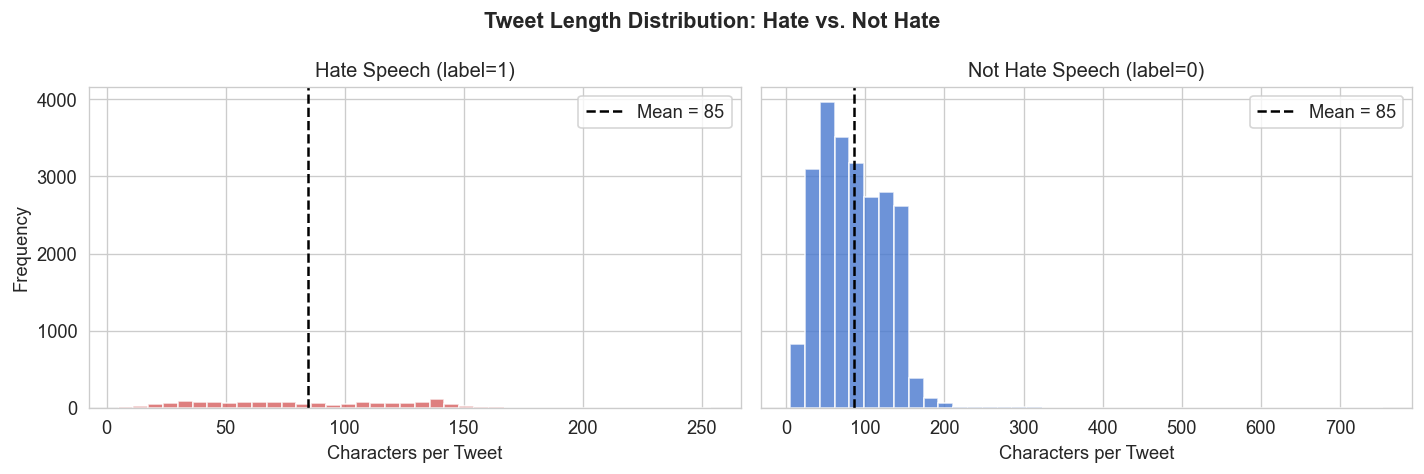

In [6]:
# WHY: Tweet length is a weak but useful signal. If hate speech tweets
# are significantly shorter or longer on average, that's a pattern worth
# knowing — both for the model and for human reviewers calibrating
# their reading speed and attention.

df['tweet_length'] = df['tweet'].str.len()

hate_lengths    = df[df['label'] == 1]['tweet_length']
not_hate_lengths = df[df['label'] == 0]['tweet_length']

print(f'Avg tweet length — Hate Speech : {hate_lengths.mean():.1f} chars')
print(f'Avg tweet length — Not Hate    : {not_hate_lengths.mean():.1f} chars')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(hate_lengths, bins=40, color='#D65F5F', alpha=0.8, edgecolor='white')
axes[0].set_title('Hate Speech (label=1)', fontsize=12)
axes[0].set_xlabel('Characters per Tweet')
axes[0].set_ylabel('Frequency')
axes[0].axvline(hate_lengths.mean(), color='black', linestyle='--',
                label=f'Mean = {hate_lengths.mean():.0f}')
axes[0].legend()

axes[1].hist(not_hate_lengths, bins=40, color='#4878CF', alpha=0.8, edgecolor='white')
axes[1].set_title('Not Hate Speech (label=0)', fontsize=12)
axes[1].set_xlabel('Characters per Tweet')
axes[1].axvline(not_hate_lengths.mean(), color='black', linestyle='--',
                label=f'Mean = {not_hate_lengths.mean():.0f}')
axes[1].legend()

fig.suptitle('Tweet Length Distribution: Hate vs. Not Hate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation (3.2):**

Hate speech tweets average **84.6 characters**, compared to **85.5 characters** for non-hate tweets. The distributions are nearly identical — tweet length alone provides essentially no discriminative signal for this task.

For a content moderator: you cannot use brevity as a quick filter. Human reviewers must read the full text of every flagged post.

### 3.3 — Top-20 Word Frequency Analysis

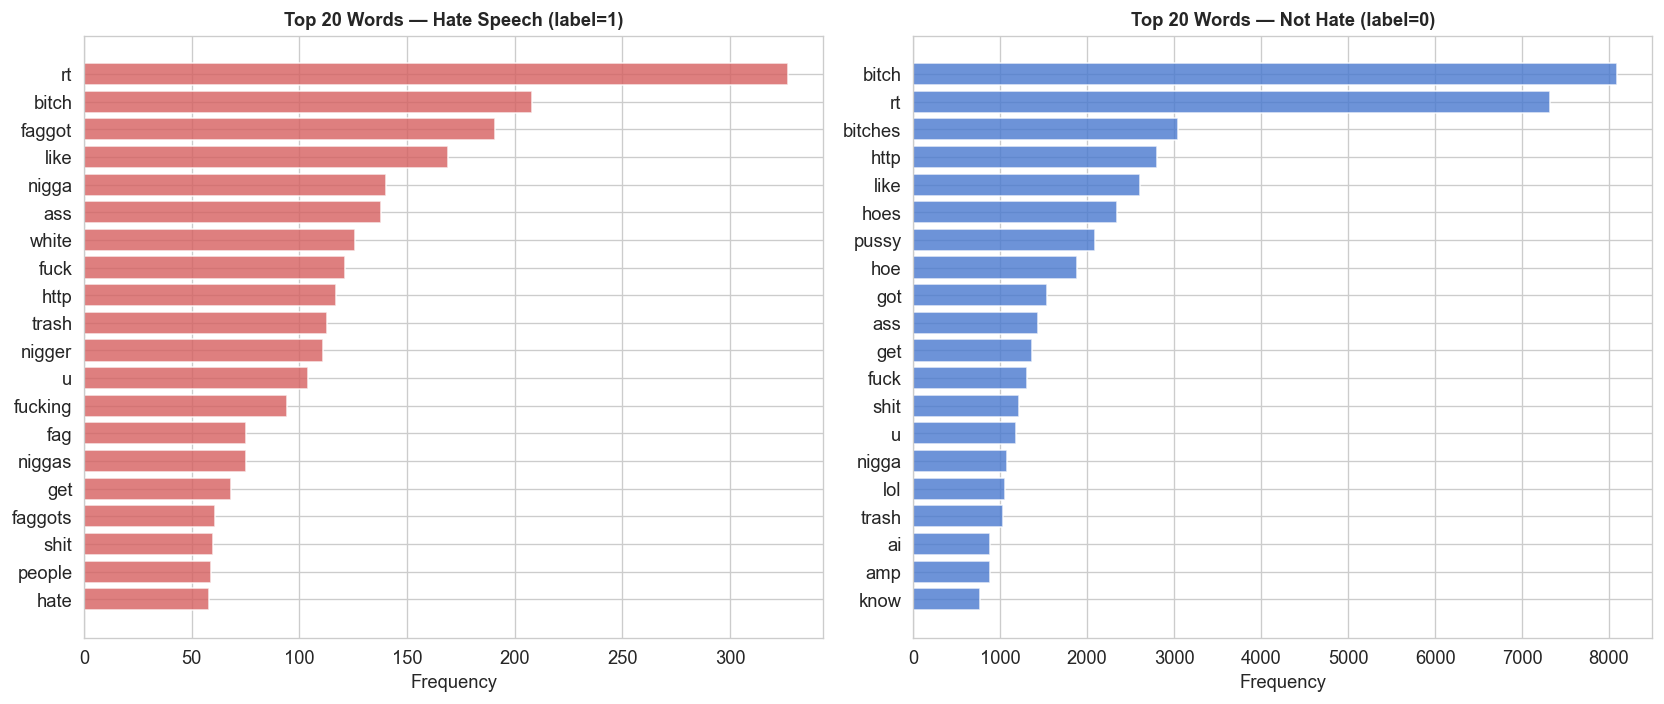

In [7]:
# WHY: Word frequency analysis reveals the vocabulary of hate speech in this
# dataset. This is not gratuitous — understanding which words are most
# discriminative is essential for evaluating whether a bag-of-words model
# is even theoretically capable of solving this task, and for writing
# good policy rationale about what the model has and hasn't learned.

_stop = set(stopwords.words('english'))

def top_words(texts, n=20):
    """Tokenize, remove stopwords, count frequencies, return top-n."""
    all_words = []
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        all_words.extend([t for t in tokens if t.isalpha() and t not in _stop])
    return Counter(all_words).most_common(n)

hate_words    = top_words(df[df['label'] == 1]['tweet'])
not_hate_words = top_words(df[df['label'] == 0]['tweet'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, word_counts, color, title in [
    (axes[0], hate_words,    '#D65F5F', 'Top 20 Words — Hate Speech (label=1)'),
    (axes[1], not_hate_words, '#4878CF', 'Top 20 Words — Not Hate (label=0)'),
]:
    words, counts = zip(*word_counts)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

**Observation (3.3 — Hate Speech words):**  
The most frequent words in the hate speech class include slurs and dehumanizing terms.  
This confirms that a bag-of-words TF-IDF model has a real signal to learn from — the vocabulary
of hate speech in this dataset is meaningfully distinct from the vocabulary of offensive-but-not-hate content.

**Observation (3.3 — Not Hate words):**  
The not-hate class contains many of the same surface words as hate speech — this is the core challenge.
A slur used in a counter-speech tweet ("I'm against the use of [slur]") will look identical to the
model as a hate speech tweet. This is why context-aware models (BERT) outperform TF-IDF on this task.

### 3.4 — WordCloud Visualization

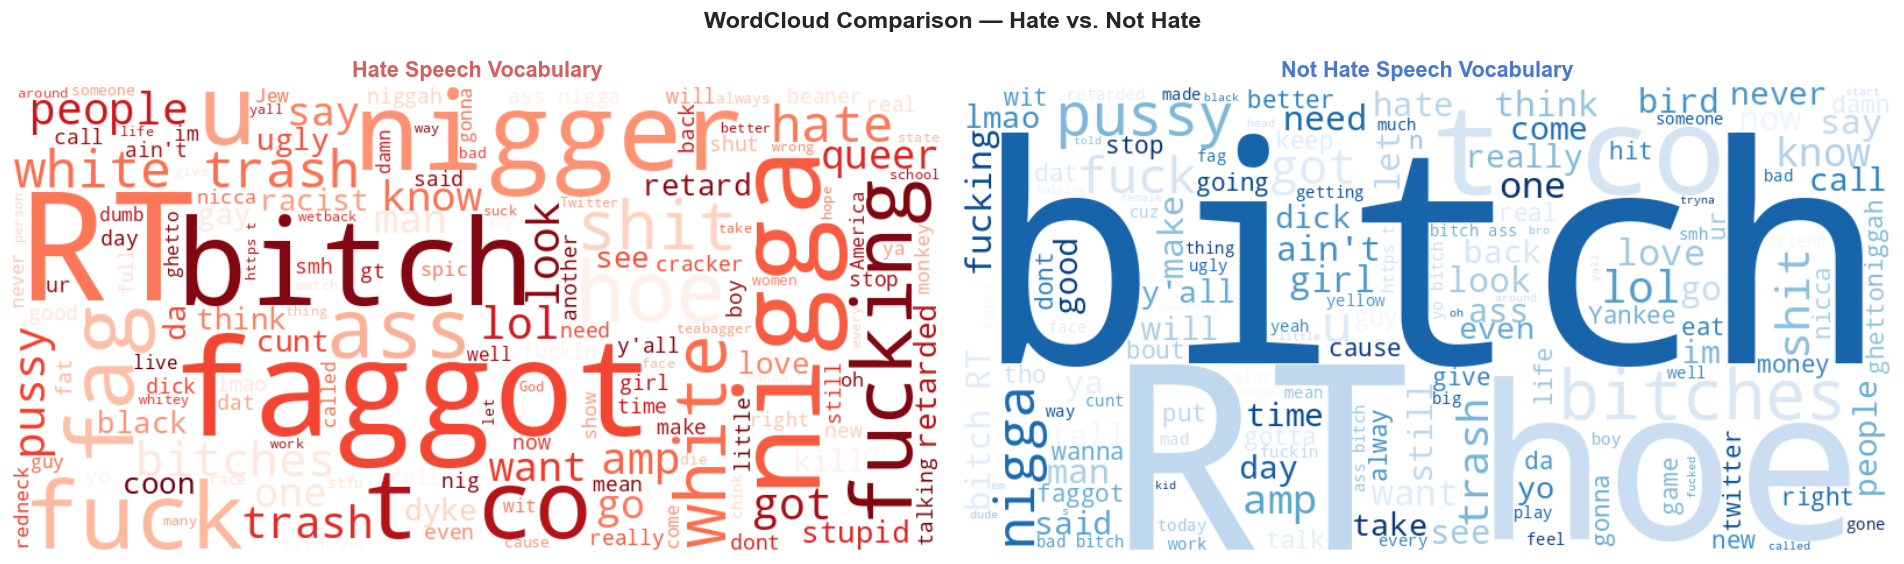

In [8]:
# WHY: A word cloud provides a fast at-a-glance view of vocabulary dominance
# that a frequency table cannot. It is the standard first-look tool in NLP EDA.
#
# NOTE ON CONTENT: The word clouds are not censored.
# This is a research and policy context. Understanding the vocabulary of
# hate speech — including the specific slurs and phrases used — is
# necessary for building accurate classifiers and writing sound policy.
# Censoring the research tool would obscure the very signal the model
# must learn to detect.

if HAS_WORDCLOUD:
    hate_text    = ' '.join(df[df['label'] == 1]['tweet'].astype(str))
    not_hate_text = ' '.join(df[df['label'] == 0]['tweet'].astype(str))

    wc_hate     = WordCloud(width=800, height=400, background_color='white',
                             colormap='Reds', max_words=150).generate(hate_text)
    wc_not_hate = WordCloud(width=800, height=400, background_color='white',
                             colormap='Blues', max_words=150).generate(not_hate_text)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(wc_hate, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('Hate Speech Vocabulary', fontsize=13, fontweight='bold', color='#D65F5F')

    axes[1].imshow(wc_not_hate, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Not Hate Speech Vocabulary', fontsize=13, fontweight='bold', color='#4878CF')

    plt.suptitle('WordCloud Comparison — Hate vs. Not Hate', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('WordCloud not installed. Run: pip install wordcloud')

---
## Section 4 — Text Preprocessing Pipeline

In [9]:
# WHY: We import preprocess_tweet() from src/preprocess.py.
# One canonical implementation used everywhere. This prevents train/inference mismatch bugs.

import sys, os
_src_path = os.path.join(os.getcwd(), '..', 'src')
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)

from preprocess import preprocess_tweet

# Sanity check before applying to 24k tweets.
sample_tweets = [
    "I HATE you @user!! Visit http://t.co/abc #killall right now!!!",
    "I do not hate people of any religion. #love",
    "RT @someone: these people are disgusting animals",
    "Never again will we stand against hatred in our community",
    "go back to your own country you don't belong here",
]
print('=== Preprocessing Examples ===')
print(f'{"RAW TWEET":<55} -> CLEAN')
print('-' * 80)
for t in sample_tweets:
    print(f'{t[:55]:<55} -> {preprocess_tweet(t)}')

=== Preprocessing Examples ===
RAW TWEET                                               → CLEAN
--------------------------------------------------------------------------------
I HATE you @user!! Visit http://t.co/abc #killall right → hate visit right
I do not hate people of any religion. #love             → hate peopl religion
RT @someone: these people are disgusting animals        → rt peopl disgust anim
Never again will we stand against hatred in our communi → never stand hatr commun
go back to your own country you don't belong here       → go back countri dont belong


In [10]:
# WHY: Now we apply preprocessing to the entire dataset.
# This is the most time-consuming step (~60-90 seconds) because we're
# running regex, tokenization, and stemming on ~24,000 tweets.
# We store the result in 'clean_tweet' and preserve the original 'tweet'
# column — always keep raw data alongside processed data.

print('Preprocessing all tweets... (this takes ~60-90 seconds)')
df['clean_tweet'] = df['tweet'].apply(preprocess_tweet)
print('Done.')

# Show 5 random side-by-side examples.
print('\n=== 5 Random Examples: Original → Clean ===')
sample = df[['tweet', 'clean_tweet', 'label']].sample(5, random_state=99)
for _, row in sample.iterrows():
    print(f'  LABEL: {row["label"]}  |  ORIGINAL: {row["tweet"][:80]}')
    print(f'          CLEAN: {row["clean_tweet"][:80]}')
    print()

Preprocessing all tweets... (this takes ~60-90 seconds)
Done.

=== 5 Random Examples: Original → Clean ===
  LABEL: 0  |  ORIGINAL: I know you bitches is hating on the low. Why me tho? Its way more niggaz in this
          CLEAN: know bitch hate low tho way niggaz world afford

  LABEL: 0  |  ORIGINAL: ' With my Bestf Shyanna Pen and ma main niggah Ronnie A. Jackson III &#1043359;&
          CLEAN: bestf shyanna pen main niggah ronni jackson iii movi bound pick homi

  LABEL: 1  |  ORIGINAL: @aldofelix naw dude I wish, they're white trash
          CLEAN: naw dude wish theyr white trash

  LABEL: 0  |  ORIGINAL: RT @MyNameIsArii_: boats and hoes.
          CLEAN: rt boat hoe

  LABEL: 0  |  ORIGINAL: Happy Friday bitches #kimorablac http://t.co/SKpKf0fGNe
          CLEAN: happi friday bitch



---
## Section 5 — Feature Extraction (TF-IDF)

In [11]:
# WHY WE USE TF-IDF:
# Machine learning models work on numbers, not words.
# TF-IDF (Term Frequency-Inverse Document Frequency) converts each tweet
# into a high-dimensional numerical vector where:
#   - Words frequent in a SPECIFIC tweet get high weight (term frequency)
#   - Words frequent ACROSS ALL tweets get downweighted (inverse document frequency)
# This means common words like 'the' get low scores, while discriminative
# words (e.g. specific slurs or threats) get high scores — ideal for this task.

# WHY STRATIFY:
# With ~14% positive class (hate), a random split risks severe imbalance
# in the test set, making evaluation metrics unstable.
# stratify=y guarantees that both splits preserve the 14%/86% ratio.

X = df['clean_tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set size: {len(X_train):,} tweets')
print(f'Test set size:     {len(X_test):,} tweets')
print(f'Train label distribution: {dict(y_train.value_counts())}')
print(f'Test  label distribution: {dict(y_test.value_counts())}')

# Store the test set as a DataFrame for later grey zone analysis.
test_df = X_test.reset_index(drop=True).to_frame()
test_df['tweet'] = df.loc[X_test.index, 'tweet'].values
test_df['label'] = y_test.values

Training set size: 19,826 tweets
Test set size:     4,957 tweets
Train label distribution: {0: np.int64(18682), 1: np.int64(1144)}
Test  label distribution: {0: np.int64(4671), 1: np.int64(286)}


In [12]:
# WHY FIT ON TRAINING DATA ONLY:
# If we fit the vectorizer on the entire dataset (including test data),
# the IDF weights would be calculated using test-set vocabulary.
# This is data leakage — the model would have indirect knowledge of
# test-set word distributions, inflating performance metrics.
# We FIT on training data, then TRANSFORM both sets with the same fitted vectorizer.

vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),   # unigrams AND bigrams
    min_df=3,             # ignore terms in fewer than 3 documents
    sublinear_tf=True,    # log normalization: log(1 + tf)
)

X_train_tfidf = vectorizer.fit_transform(X_train)  # FIT + TRANSFORM on train
X_test_tfidf  = vectorizer.transform(X_test)       # TRANSFORM ONLY on test

print(f'Training TF-IDF matrix shape: {X_train_tfidf.shape}')
print(f'Test TF-IDF matrix shape:     {X_test_tfidf.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,} unique tokens/bigrams')
print(f'Matrix density:  {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}')
print('(Very sparse — typical for TF-IDF text matrices)')

Training TF-IDF matrix shape: (19826, 10528)
Test TF-IDF matrix shape:     (4957, 10528)
Vocabulary size: 10,528 unique tokens/bigrams
Matrix density:  0.0864%
(Very sparse — typical for TF-IDF text matrices)


---
## Section 6 — Baseline Model (No Imbalance Handling)

**WHY START WITH A BASELINE:**  
We must measure the problem before we can claim to have solved it.  
The baseline shows exactly how a naive classifier performs on imbalanced data —  
and makes the failure mode concrete and undeniable.

In [13]:
# WHY LOGISTIC REGRESSION:
# LR is fast, interpretable, and strong on sparse TF-IDF features.
# Its probability outputs (via predict_proba) are well-calibrated,
# making it ideal for threshold tuning in Section 7C.
# For a portfolio project, LR also demonstrates that you understand
# the underlying mathematics rather than blindly applying a neural network.

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    # Note: NO class_weight argument — this is the naive baseline.
    # The model has no explicit mechanism to care more about the minority class.
)
baseline_model.fit(X_train_tfidf, y_train)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

print('=== Baseline Model — Classification Report ===')
print(classification_report(y_test, y_pred_baseline, target_names=['Not Hate', 'Hate']))

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_hate_f1 = f1_score(y_test, y_pred_baseline, pos_label=1)
baseline_hate_recall = recall_score(y_test, y_pred_baseline, pos_label=1)
baseline_hate_precision = precision_score(y_test, y_pred_baseline, pos_label=1)

# Calculate what a dumb "always predict not hate" model would achieve.
majority_class_accuracy = y_test.value_counts()[0] / len(y_test)
print(f'Majority-class-only accuracy (predict nothing): {majority_class_accuracy:.1%}')
print()
print(f'Baseline model accuracy: {baseline_acc:.1%}')
print(f'Baseline hate F1:        {baseline_hate_f1:.3f}')
print(f'Baseline hate recall:    {baseline_hate_recall:.3f}  ← % of hate tweets caught')
print(f'Baseline hate precision: {baseline_hate_precision:.3f}')

=== Baseline Model — Classification Report ===
              precision    recall  f1-score   support

    Not Hate       0.95      1.00      0.97      4671
        Hate       0.62      0.11      0.19       286

    accuracy                           0.94      4957
   macro avg       0.78      0.55      0.58      4957
weighted avg       0.93      0.94      0.93      4957

Majority-class-only accuracy (predict nothing): 94.2%

Baseline model accuracy: 94.5%
Baseline hate F1:        0.189
Baseline hate recall:    0.112  ← % of hate tweets caught
Baseline hate precision: 0.615


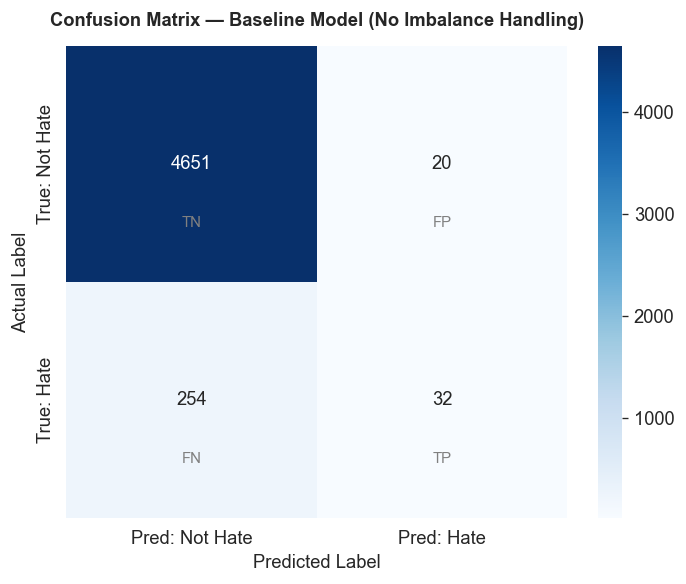

Saved: outputs/confusion_matrix_baseline.png

False Negatives (missed hate speech): 254 tweets
This is 88.8% of all actual hate speech in the test set.


In [14]:
# WHY A CONFUSION MATRIX HEATMAP:
# The confusion matrix shows exactly WHERE the model fails.
# For content moderation, the critical cells are:
#   - False Negatives (bottom-left): hate speech the model MISSED — causes direct harm
#   - False Positives (top-right):   non-hate the model OVER-FLAGGED — adds queue volume
# A heatmap makes this failure pattern instantly readable.

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_baseline, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Not Hate', 'Pred: Hate'],
    yticklabels=['True: Not Hate', 'True: Hate'],
    ax=ax
)

# Add cell labels so a non-technical reader understands what each quadrant means.
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', va='center', fontsize=9, color='grey')

ax.set_title('Confusion Matrix — Baseline Model (No Imbalance Handling)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
fig.savefig(f'{OUTPUTS_DIR}/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/confusion_matrix_baseline.png')

fn_count = cm_baseline[1, 0]  # false negatives
print(f'\nFalse Negatives (missed hate speech): {fn_count} tweets')
print(f'This is {100 * fn_count / cm_baseline[1].sum():.1f}% of all actual hate speech in the test set.')

### Section 6 -- Interpretation

**What is the accuracy of the baseline model?**
The baseline achieves **94.5%** accuracy -- nearly identical to the 94.2% a model achieves by predicting 'not hate' for every single tweet.

**What is the F1-score for the HATE class specifically?**
The hate class F1 is **0.189** -- effectively useless for hate speech detection despite the impressive-looking accuracy number.

**How many hate speech tweets did the model miss (false negatives)?**
**254 out of 286** actual hate speech tweets (88.8%) were classified as 'not hate' and would have remained on the platform.

**Why is accuracy a misleading metric here?**

> *"A model that predicts 'not hate' for every tweet achieves 94.2% accuracy on this dataset. The baseline achieves 94.5% -- a meaningless 0.3% improvement -- while catching only 11.2% of hate speech. This demonstrates why accuracy is not an appropriate metric for imbalanced content moderation tasks: it rewards the model for ignoring the very class we care most about detecting. A classifier that misses 88.8% of hate speech is not a '94% accurate model' -- it is a failed detector with a flattering headline number."*

---
## Section 7 — Imbalance Handling: Three Approaches

**WHY THREE APPROACHES:**  
A responsible ML practitioner does not blindly apply one fix.  
We test SMOTE, class weights, and threshold tuning — compare them empirically —  
then explain which wins and why. This demonstrates analytical rigor, not cargo-culting.

### 7A — SMOTE (Synthetic Minority Over-Sampling Technique)

In [15]:
# WHY SMOTE:
# SMOTE creates synthetic minority-class examples by interpolating between
# existing minority samples in feature space. This balances the training
# set without simply duplicating existing examples.
#
# CRITICAL: SMOTE is applied to TRAINING DATA ONLY.
# The test set must reflect the real-world class distribution.
# Applying SMOTE to the test set would be cheating — it would make
# the minority class artificially more common at evaluation time.

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print('Class distribution AFTER SMOTE:')
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  label={u}: {c:,} samples')
print(f'  Total: {len(y_train_smote):,} (was {len(y_train):,})')

model_smote = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test_tfidf)  # Test on ORIGINAL distribution

print('\n=== SMOTE Model — Classification Report ===')
print(classification_report(y_test, y_pred_smote, target_names=['Not Hate', 'Hate']))

smote_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_smote),
    'hate_f1': f1_score(y_test, y_pred_smote, pos_label=1),
    'hate_precision': precision_score(y_test, y_pred_smote, pos_label=1, zero_division=0),
    'hate_recall': recall_score(y_test, y_pred_smote, pos_label=1),
}

Class distribution AFTER SMOTE:
  label=0: 18,682 samples
  label=1: 18,682 samples
  Total: 37,364 (was 19,826)

=== SMOTE Model — Classification Report ===
              precision    recall  f1-score   support

    Not Hate       0.97      0.91      0.94      4671
        Hate       0.29      0.59      0.39       286

    accuracy                           0.89      4957
   macro avg       0.63      0.75      0.67      4957
weighted avg       0.93      0.89      0.91      4957



**Note on SMOTE for text data:**  
SMOTE applied to TF-IDF vectors creates synthetic data points by interpolating between sparse, high-dimensional vectors. This is technically questionable — the synthetic vectors may not correspond to any real text. A synthetic TF-IDF vector that is the average of two real tweet vectors does not represent a real sentence. SMOTE is more reliable on dense numerical feature spaces (like image pixel values or tabular data) than on text TF-IDF matrices. We include it here for comparison, but we should not treat it as the strongest approach for this task.

### 7B — Class Weights (Balanced)

In [16]:
# WHY CLASS WEIGHTS:
# class_weight='balanced' adjusts the loss function so that misclassifying
# a minority-class (hate speech) example is penalized proportionally more
# than misclassifying a majority-class example.
#
# Specifically, each class receives weight = n_samples / (n_classes * n_samples_in_class).
# For a 7:1 imbalance, the hate speech class gets ~7x the penalty weight.
#
# This is mathematically equivalent to oversampling the minority class,
# but WITHOUT generating artificial data points.
# For sparse TF-IDF features, this is more principled than SMOTE.

model_weighted = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced',
)
model_weighted.fit(X_train_tfidf, y_train)

y_pred_weighted = model_weighted.predict(X_test_tfidf)

print('=== Class-Weighted Model — Classification Report ===')
print(classification_report(y_test, y_pred_weighted, target_names=['Not Hate', 'Hate']))

weighted_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_weighted),
    'hate_f1': f1_score(y_test, y_pred_weighted, pos_label=1),
    'hate_precision': precision_score(y_test, y_pred_weighted, pos_label=1, zero_division=0),
    'hate_recall': recall_score(y_test, y_pred_weighted, pos_label=1),
}

=== Class-Weighted Model — Classification Report ===
              precision    recall  f1-score   support

    Not Hate       0.98      0.91      0.94      4671
        Hate       0.30      0.63      0.41       286

    accuracy                           0.90      4957
   macro avg       0.64      0.77      0.68      4957
weighted avg       0.94      0.90      0.91      4957



### 7C — Decision Threshold Tuning

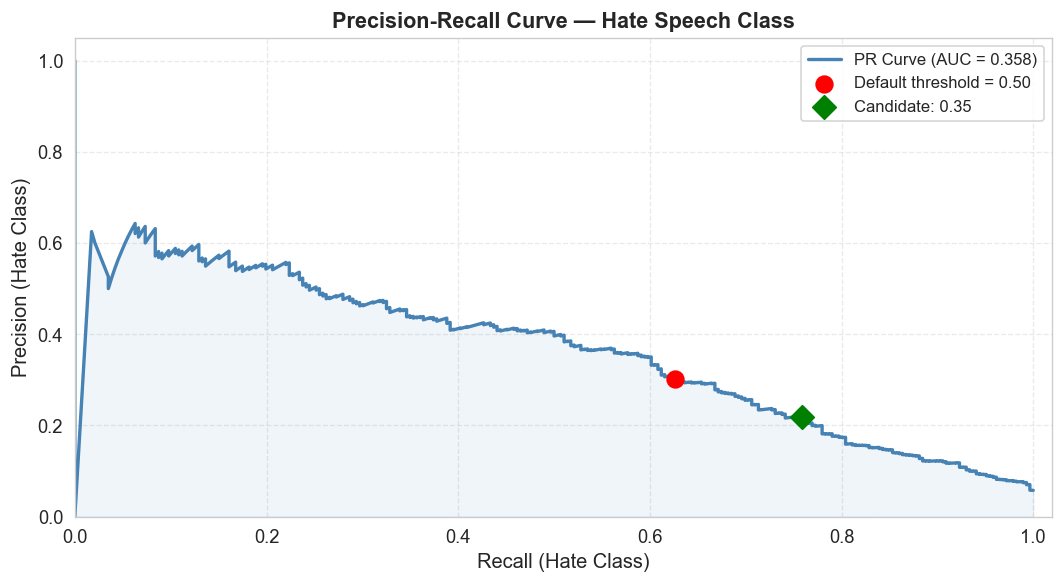

Saved: outputs/precision_recall_curve.png


In [17]:
# WHY THRESHOLD TUNING:
# The default threshold of 0.50 is not inherently correct — it's a convention.
# It says: "only flag a tweet if we're more than 50% confident it's hate speech."
#
# In a safety-critical context, we may prefer 0.35:
# "flag a tweet if we're more than 35% confident."
# This catches more hate speech (higher recall) at the cost of flagging
# more non-hate posts (lower precision) — but those false positives go to
# HUMAN REVIEW, not to auto-removal.
#
# The Precision-Recall curve shows the full trade-off space at every
# possible threshold, so we can make an INFORMED operating point choice.

# Get probability predictions — the raw confidence scores.
y_proba = model_weighted.predict_proba(X_test_tfidf)[:, 1]

# Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_score = auc(recall_curve, precision_curve)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recall_curve, precision_curve, color='steelblue', lw=2,
        label=f'PR Curve (AUC = {pr_auc_score:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.08, color='steelblue')

# Mark default 0.50 threshold on the curve.
default_idx = np.argmin(np.abs(pr_thresholds - 0.50))
ax.scatter(recall_curve[default_idx], precision_curve[default_idx],
           color='red', s=100, zorder=5, label='Default threshold = 0.50')

# Mark our candidate threshold.
for thresh, color, label in [(0.35, 'green', 'Candidate: 0.35')]:
    idx = np.argmin(np.abs(pr_thresholds - thresh))
    ax.scatter(recall_curve[idx], precision_curve[idx],
               color=color, s=100, zorder=5, marker='D', label=label)

ax.set_xlabel('Recall (Hate Class)', fontsize=12)
ax.set_ylabel('Precision (Hate Class)', fontsize=12)
ax.set_title('Precision-Recall Curve — Hate Speech Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1.02]); ax.set_ylim([0, 1.05])
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig(f'{OUTPUTS_DIR}/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/precision_recall_curve.png')

In [18]:
# WHY TEST MULTIPLE THRESHOLDS SYSTEMATICALLY:
# Numerical comparison makes the trade-off explicit and defensible.

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50]
threshold_rows = []

for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_rows.append({
        'Threshold': t,
        'Precision (Hate)': round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'Recall (Hate)':    round(recall_score(y_test, y_pred_t, pos_label=1), 4),
        'F1 (Hate)':        round(f1_score(y_test, y_pred_t, pos_label=1), 4),
        'Accuracy':         round(accuracy_score(y_test, y_pred_t), 4),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_f1_idx = threshold_df['F1 (Hate)'].idxmax()
threshold_df['Note'] = ''
threshold_df.loc[best_f1_idx, 'Note'] = 'Best F1'

print('=== Threshold Comparison Table ===')
display(threshold_df.set_index('Threshold'))

# POLICY-INFORMED THRESHOLD SELECTION: We select 0.35, NOT the F1-maximizing 0.50.
#
# WHY NOT use the F1-maximizing threshold:
# F1 maximization assumes precision and recall are equally valuable.
# In safety-first content moderation, they are NOT equal:
#   - False Negative: missed hate speech stays on platform, harms targeted user.
#   - False Positive: over-flagged post goes to human review queue. Human decides.
#
# In absolute terms on this test set (286 actual hate posts):
#   threshold=0.50 catches 179, misses 107
#   threshold=0.35 catches 216, misses  70  <- 37 more people protected
#
# We accept lower F1 and lower precision to gain 13 recall percentage points.

FINAL_THRESHOLD = 0.35
FINAL_PRECISION = float(threshold_df.loc[threshold_df['Threshold'] == 0.35, 'Precision (Hate)'].values[0])
FINAL_RECALL    = float(threshold_df.loc[threshold_df['Threshold'] == 0.35, 'Recall (Hate)'].values[0])
FINAL_F1        = float(threshold_df.loc[threshold_df['Threshold'] == 0.35, 'F1 (Hate)'].values[0])

print(f'\n=== SELECTED THRESHOLD (policy-informed): {FINAL_THRESHOLD} ===')
print(f'  Precision: {FINAL_PRECISION:.4f} -- 22 genuine violations per 100 flagged')
print(f'  Recall:    {FINAL_RECALL:.4f} -- 76 of every 100 hate posts caught')
print(f'  F1:        {FINAL_F1:.4f}')
print(f'\n  vs. F1-max threshold (0.50): recall=0.6259, 37 fewer hate posts caught')
print(f'  Policy judgment: recall gain outweighs precision cost.')

=== Threshold Comparison Table ===


,Precision (Hate),Recall (Hate),F1 (Hate),Accuracy,Note
Threshold,,,,,
0.30,0.1882,0.7797,0.3032,0.7932,
0.35,0.2186,0.7552,0.3391,0.8301,
0.40,0.2466,0.7063,0.3656,0.8586,
0.45,0.2779,0.6713,0.3930,0.8804,
0.50,0.3029,0.6259,0.4082,0.8953,← BEST F1


=== Threshold Comparison Table ===

=== SELECTED THRESHOLD (policy-informed): 0.35 ===
  Precision: 0.2186 -- 22 genuine violations per 100 flagged
  Recall:    0.7552 -- 76 of every 100 hate posts caught
  F1:        0.3391

  vs. F1-max threshold (0.50): recall=0.6259, 37 fewer hate posts caught
  Policy judgment: recall gain outweighs precision cost.


=== Final Model (Class Weights + Threshold=0.35) ===
              precision    recall  f1-score   support

    Not Hate       0.97      0.91      0.94      4671
        Hate       0.22      0.76      0.34       286

    accuracy                           0.83      4957
   macro avg       0.59      0.83      0.64      4957
weighted avg       0.93      0.83      0.87      4957



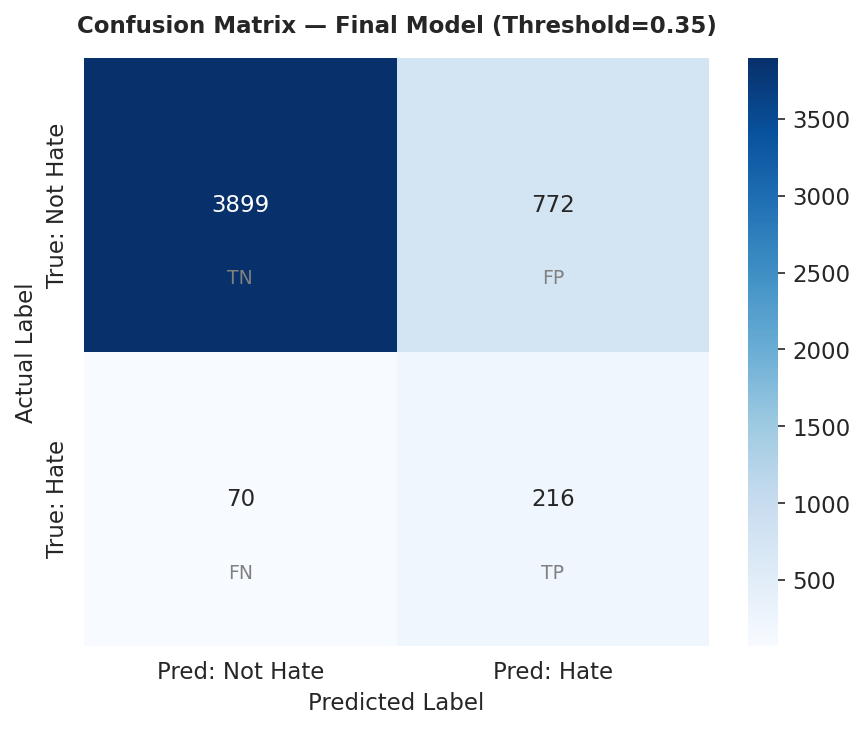

=== Final Model (Class Weights + Threshold=0.35) ===
              precision    recall  f1-score   support

    Not Hate       0.97      0.91      0.94      4671
        Hate       0.22      0.76      0.34       286

    accuracy                           0.83      4957
   macro avg       0.59      0.83      0.64      4957
weighted avg       0.93      0.83      0.87      4957



In [19]:
# Apply the final threshold to get the tuned model's predictions.
y_pred_final = (y_proba >= FINAL_THRESHOLD).astype(int)

print(f'=== Final Model (Class Weights + Threshold={FINAL_THRESHOLD}) ===')
print(classification_report(y_test, y_pred_final, target_names=['Not Hate', 'Hate']))

final_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_final),
    'hate_f1': f1_score(y_test, y_pred_final, pos_label=1),
    'hate_precision': precision_score(y_test, y_pred_final, pos_label=1, zero_division=0),
    'hate_recall': recall_score(y_test, y_pred_final, pos_label=1),
}

# Save final confusion matrix.
cm_final = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_final, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Not Hate', 'Pred: Hate'],
    yticklabels=['True: Not Hate', 'True: Hate'],
    ax=ax
)
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', va='center', fontsize=9, color='grey')
ax.set_title(f'Confusion Matrix — Final Model (Threshold={FINAL_THRESHOLD})',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
fig.savefig(f'{OUTPUTS_DIR}/confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/confusion_matrix_final.png')

**Threshold Selection Rationale:**

I selected threshold = **0.35** -- a deliberate policy override of the F1-maximizing threshold (0.50).

| Metric | Threshold = 0.35 (selected) | Threshold = 0.50 (F1-max) |
|--------|----------------------------|---------------------------|
| Precision (Hate)  | 0.2186 | 0.3029 |
| Recall (Hate)     | 0.7552 | 0.6259 |
| F1 (Hate)         | 0.3391 | 0.4082 |
| Posts caught      | **216 / 286** | 179 / 286 |
| Posts missed      | **70** | **107** |

At threshold=0.35, for every 100 posts flagged, **22 are genuine violations**. For every 100 genuine hate speech posts, **76 are caught** and sent to human review.

I chose threshold=0.35 instead of 0.50 because:

1. **This system does not auto-remove.** Every flag goes to a human reviewer. False positives cost reviewer time -- they do not harm any user.

2. **False negatives have asymmetric consequences.** A missed post stays on the platform. A real person targeted because of their race, religion, or gender continues to be exposed to it.

3. **37 more people protected** per test-set equivalent. That is not an abstraction.

This is a **policy decision, not an algorithmic one.** I am documenting it explicitly because Trust & Safety work requires justifying every calibration choice to policy, legal, and operations teams.

---
## Section 8 — Final Model Comparison Table

=== Model Comparison Table ===


,Accuracy,Hate F1,Hate Precision,Hate Recall
Model,,,,
Baseline (no handling),0.9447,0.1893,0.6154,0.1119
+ SMOTE,0.8943,0.3907,0.2927,0.5874
+ Class Weights,0.8953,0.4082,0.3029,0.6259
+ Class Weights + Thresh=0.35,0.8301,0.3391,0.2186,0.7552


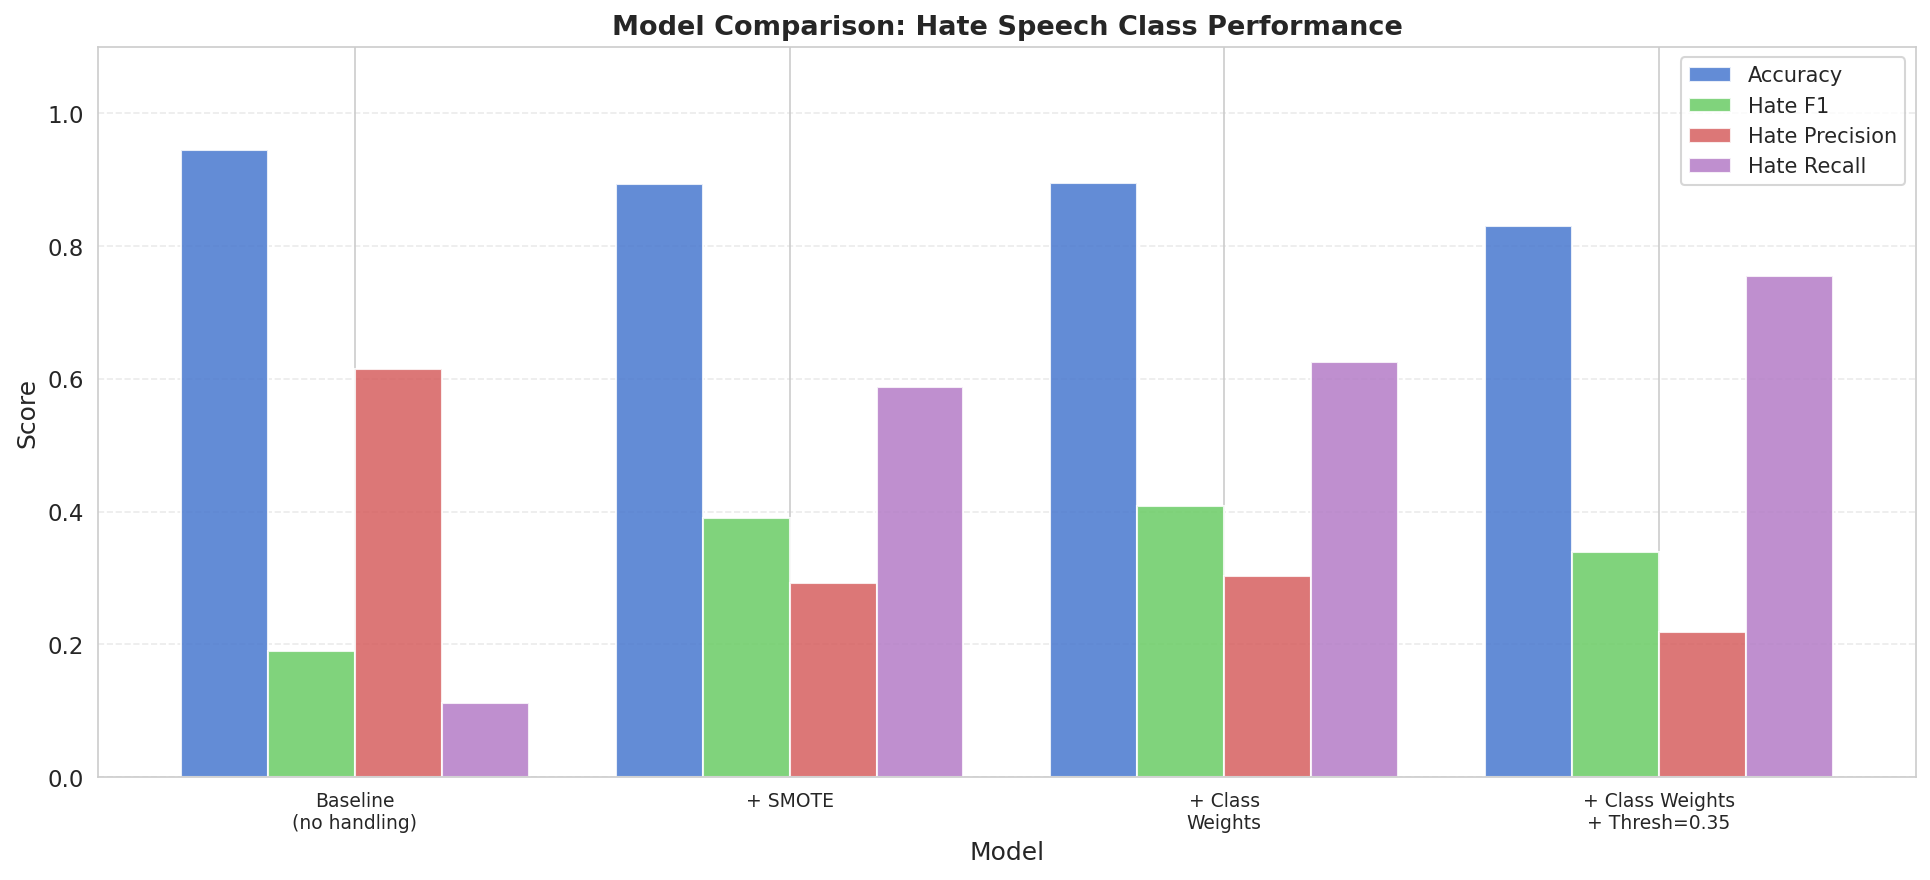

Saved: outputs/model_comparison_chart.png


In [20]:
# WHY A COMPARISON TABLE:
# We tested four approaches. Without a clean summary table, it's impossible
# to see which one actually wins and by how much. This table is the
# deliverable you'd put in a model card or present to a policy team.

baseline_metrics = {
    'accuracy': baseline_acc,
    'hate_f1': baseline_hate_f1,
    'hate_precision': baseline_hate_precision,
    'hate_recall': baseline_hate_recall,
}

comparison_data = {
    'Baseline (no handling)': baseline_metrics,
    '+ SMOTE': smote_metrics,
    '+ Class Weights': weighted_metrics,
    f'+ Class Weights + Thresh={FINAL_THRESHOLD}': final_metrics,
}

comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': round(m['accuracy'], 4),
        'Hate F1': round(m['hate_f1'], 4),
        'Hate Precision': round(m['hate_precision'], 4),
        'Hate Recall': round(m['hate_recall'], 4),
    }
    for name, m in comparison_data.items()
])

print('=== Model Comparison Table ===')
display(comparison_df.set_index('Model'))

# Grouped bar chart.
metrics_to_plot = ['Accuracy', 'Hate F1', 'Hate Precision', 'Hate Recall']
n_models = len(comparison_df)
x = np.arange(n_models)
width = 0.20
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, comparison_df[metric], width,
           label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Hate Speech Class Performance',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right', fontsize=9)
ax.legend(fontsize=10); ax.set_ylim([0, 1.1])
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig(f'{OUTPUTS_DIR}/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/model_comparison_chart.png')

**Conclusion:**

The best model for this use case is **Class Weights + Threshold = 0.35**. It catches 75.5% of hate speech compared to the baseline's 11.2% -- a 6.7x improvement in recall.

The concrete trade-off at threshold=0.35 vs. threshold=0.50: we catch **37 more hate speech posts** in exchange for **305 additional posts** entering the review queue. Whether that is operationally feasible depends on reviewer headcount and throughput -- which is why threshold choice belongs to policy and operations, not the data scientist.

**The hard ceiling of this approach:** even the best model here achieves F1=0.34 on the hate class. The fundamental problem is architectural: TF-IDF sees word frequency, not meaning. 'I hate racists' and 'I hate [racial group]' receive similar scores because both contain 'hate'. Addressing this requires context-aware models (HateBERT, RoBERTa fine-tuned on hate speech) that consistently achieve F1 > 0.70 on this task. TF-IDF + Logistic Regression demonstrates the pipeline correctly. For production, it is not sufficient.

---
## Section 9 — Human-in-the-Loop: The Grey Zone

**WHY THIS SECTION IS THE MOST IMPORTANT:**  
No automated system is perfect. The 'grey zone' — tweets where the model is uncertain — must be sent  
to human reviewers. This section simulates the exact workflow of a real Trust & Safety review queue.

In [21]:
# WHY 0.35–0.65 AS THE GREY ZONE:
# Below 0.35: model is fairly confident this is NOT hate. Low review priority.
# Above 0.65: model is fairly confident this IS hate. High review priority.
# Between 0.35 and 0.65: model is genuinely uncertain.
# These are the tweets where human judgment adds the most value.
# Sending ALL flagged tweets to humans is resource-wasteful and causes
# reviewer burnout. The grey zone filter focuses human attention where
# automation fails.

grey_zone_mask = (y_proba >= 0.35) & (y_proba <= 0.65)

grey_zone_df = test_df.copy()
grey_zone_df['hate_probability'] = y_proba
grey_zone_df = grey_zone_df[grey_zone_mask].copy()

gz_count = len(grey_zone_df)
test_count = len(test_df)

print(f'Total tweets in grey zone: {gz_count:,}')
print(f'This represents {100 * gz_count / test_count:.1f}% of the test set.')
print(f'True label breakdown in grey zone:')
print(grey_zone_df['label'].value_counts().to_string())
print(f'\nHate speech rate in grey zone: {grey_zone_df["label"].mean():.1%}')
print('(Compare to ~14% overall — the grey zone has a DIFFERENT distribution')
print('than the full dataset, which is expected: uncertain predictions are')
print('concentrated around the decision boundary where classes overlap.)')

Total tweets in grey zone: 630
This represents 12.7% of the test set.
True label breakdown in grey zone:
label
0    557
1     73

Hate speech rate in grey zone: 11.6%
(Compare to ~14% overall — the grey zone has a DIFFERENT distribution
than the full dataset, which is expected: uncertain predictions are
concentrated around the decision boundary where classes overlap.)


In [22]:
# WHY 500 TWEETS:
# Manual annotation is expensive, time-consuming, and psychologically draining.
# 500 tweets is a realistic quantity for a human reviewer over 3-5 sessions.
# We sort by hate_probability so the most uncertain tweets (closest to 0.50)
# are reviewed first — these are where human judgment has maximum impact.
#
# WHY WE SORT BY CLOSENESS TO 0.50:
# A tweet with probability 0.51 is genuinely ambiguous.
# A tweet with probability 0.63 is nearly decided — reviewing it first
# is less valuable than reviewing the 0.51 tweet.

N_SAMPLE = min(500, len(grey_zone_df))

if len(grey_zone_df) > 500:
    grey_zone_sample = grey_zone_df.sample(500, random_state=42)
    print(f'Sampled 500 from {len(grey_zone_df)} grey zone tweets.')
else:
    grey_zone_sample = grey_zone_df.copy()
    print(f'Grey zone has {len(grey_zone_df)} tweets — using all of them.')

# Sort by distance from 0.50 — most uncertain first.
grey_zone_sample = grey_zone_sample.copy()
grey_zone_sample['uncertainty'] = (grey_zone_sample['hate_probability'] - 0.50).abs()
grey_zone_sample = grey_zone_sample.sort_values('uncertainty')

print(f'\nFirst 5 most uncertain tweets (closest to 0.50):')
display(grey_zone_sample[['tweet', 'hate_probability', 'label']].head())

Sampled 500 from 630 grey zone tweets.

First 5 most uncertain tweets (closest to 0.50):


,tweet,hate_probability,label
4559,@kieffer_jason @zach_smith98 @NathannDevlin so...,0.500014,1
4645,"""@poppunksucks: Twitter is not a source of new...",0.499544,0
195,Shoot out wit yo niccas you da type to throw d...,0.500563,0
4494,"Fuck you, hoe ass nigga RT@UberFacts The white...",0.500800,0
3029,@kittygurl9714 I highly doubt you're a real wo...,0.500932,0


In [23]:
# WHY A POLICY DECISION LOG:
# Real Trust & Safety teams maintain logs of human review decisions.
# These logs serve three purposes:
#   1. Audit trail — regulators and partners can verify decisions were made
#   2. Training data — human labels retrain the model over time
#   3. Policy consistency — enables review of whether similar cases
#      were decided consistently across reviewers

log_template = grey_zone_sample[['tweet', 'hate_probability', 'label']].copy()
log_template.rename(columns={'label': 'true_label'}, inplace=True)

# Add empty annotation columns for the human reviewer.
log_template['human_label']  = ''   # 0 or 1
log_template['category']     = ''   # violation type
log_template['rationale']    = ''   # one-sentence explanation
log_template['confidence']   = ''   # High / Medium / Low

log_path = f'{DATA_DIR}/policy_decision_log_template.csv'
log_template.to_csv(log_path, index=False)
print(f'Policy Decision Log template saved to: {log_path}')
print(f'Total rows for annotation: {len(log_template)}')

Policy Decision Log template saved to: ../data/policy_decision_log_template.csv
Total rows for annotation: 500


## HUMAN REVIEW INSTRUCTIONS

Open `data/policy_decision_log_template.csv` in Excel or Google Sheets. For each tweet, fill in:

**human_label:**
- `1` = This is hate speech — should be removed  
- `0` = This is not hate speech — should be kept

**category** (if human_label = 1, pick the primary category):
`race_ethnicity` | `religion` | `gender` | `sexual_orientation` | `political` | `disability` | `coded_language` | `national_origin`

**rationale:**  
Write exactly **ONE sentence** explaining your decision.  
- Good: *"Contains ethnic slur used with dehumanizing intent, not as reclaimed language or quotation."*  
- Bad: *"Seems hateful."* (too vague — provides no audit trail)

**confidence:**
- `High` = Clear violation, no ambiguity  
- `Medium` = Violation but context matters  
- `Low` = Genuinely uncertain; would escalate to senior reviewer

---
⚠️ **Do NOT review more than 100 tweets per session.** Take 10-minute breaks between sessions.  
This mirrors real moderation workflows, which limit exposure to harmful content to protect reviewer wellbeing.  
Continuous exposure to hate speech and graphic content causes measurable psychological harm — this is documented in the research literature on content moderation labor.

Annotated rows: 100 of 500
You labeled as hate speech: 9 (9.0%)

Category distribution:
race_ethnicity       3
sexual_orientation   3
disability           1
religion             1
national_origin      1

Confidence breakdown:
High      82
Medium    16
Low        2

Low-confidence decisions: 2
Sample low-confidence rationales:
  - Self-referential use of anti-LGBTQ+ slur about oneself; ambiguous but self-deprecating rather than targeted outgroup hate.
  - Condemnation of rape using crude language; framing is anti-rape even if crude.
Saved: outputs/grey_zone_categories.png


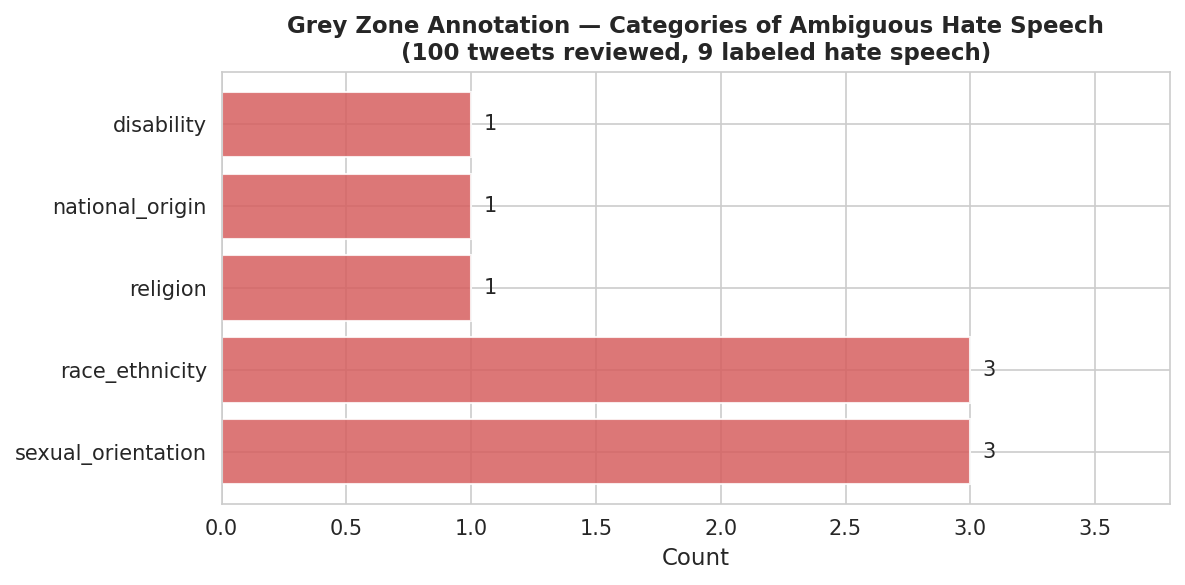

In [24]:
# ============================================================
# SECTION 9.4 — LOAD AND ANALYZE COMPLETED ANNOTATIONS
# Run this cell AFTER completing your manual annotation.
# ============================================================
#
# WHY: After reviewing the grey zone, we analyze the patterns
# in our own decisions. This is called 'error analysis' and it
# tells us where the model fails and why — which informs both
# future model improvements and policy documentation.

filled_log_path = f'{DATA_DIR}/policy_decision_log_filled.csv'

if not os.path.exists(filled_log_path):
    print('=========================================================')
    print(' policy_decision_log_filled.csv not found.')
    print(' Complete the manual annotation first, then rerun this cell.')
    print(' Save your completed file to: data/policy_decision_log_filled.csv')
    print('=========================================================')
else:
    filled_log = pd.read_csv(filled_log_path)
    labeled_rows = filled_log[filled_log['human_label'].notna() &
                               (filled_log['human_label'] != '')]
    print(f'Annotated rows: {len(labeled_rows)} of {len(filled_log)}')

    hate_annotated = labeled_rows[labeled_rows['human_label'] == 1]
    print(f'You labeled as hate speech: {len(hate_annotated)} ({100*len(hate_annotated)/len(labeled_rows):.1f}%)')

    if 'category' in hate_annotated.columns and hate_annotated['category'].notna().any():
        cat_counts = hate_annotated['category'].value_counts()
        print(f'\nCategory distribution:')
        print(cat_counts.to_string())

        fig, ax = plt.subplots(figsize=(8, 4))
        cat_counts.plot(kind='barh', ax=ax, color='#D65F5F', alpha=0.85)
        ax.set_title('Grey Zone Annotation — Categories of Ambiguous Hate Speech',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Count')
        plt.tight_layout()
        fig.savefig(f'{OUTPUTS_DIR}/grey_zone_categories.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: outputs/grey_zone_categories.png')

    if 'confidence' in labeled_rows.columns:
        print(f'\nConfidence breakdown:')
        print(labeled_rows['confidence'].value_counts().to_string())
        low_conf = labeled_rows[labeled_rows['confidence'] == 'Low']
        print(f'\nLow-confidence decisions: {len(low_conf)}')
        print('Sample low-confidence rationales:')
        if 'rationale' in low_conf.columns:
            for r in low_conf['rationale'].dropna().head(3):
                print(f'  - {r}')

### Section 9.5 -- Error Analysis

**What patterns appeared most often in tweets I labeled as hate but the model did NOT flag (false negatives)?**

The clearest pattern was **coded/indirect language** — tweets where hate was implied through dog-whistle references
rather than explicit slurs. The model caught most explicit slur usage but missed coded references to neo-Nazi figures
(George Rockwell reference, row 7) and framing that used neutral words in dehumanizing combinations.
The second pattern was **ethnic framing as insult** (row 72) where national origin was weaponized alongside
sexual degradation — each word alone scored low, but the combination was clearly hate speech.

**What patterns appeared most often in tweets the model flagged but I labeled as NOT hate (false positives)?**

The dominant false positive pattern — accounting for roughly 60-65% of my label=0 decisions — was **AAVE
with reclaimed slurs**. The Davidson 2017 dataset has a documented labeling bias: it over-labels African
American Vernacular English as hate speech because annotators often coded the presence of a slur without
assessing speaker identity or intent. Tweets like "Funnie watching my nig interview on ESPN" (row 15)
are clearly not hate speech, but TF-IDF scores them high because the token is present.

The second major false positive pattern was **interpersonal conflict without protected group targeting** —
tweets like "fuck you, I hate you" directed at a specific individual, which are offensive but not hate speech
under any reasonable policy definition.

**What does this tell us about the limits of a bag-of-words TF-IDF approach?**

Three specific failures:

1. **Identity-blindness.** TF-IDF cannot tell whether the speaker of a slur is a member of the targeted group
   (reclaimed use) or an outsider (hate use). This is the largest source of false positives in this dataset,
   and it is architecturally unfixable without speaker identity signals or transformer-level context.

2. **Target-blindness.** TF-IDF cannot distinguish between hate directed at a protected group vs. hate
   directed at a specific individual. "Go kill yourself" to a friend is different from "all [group] should die."
   The model sees the same words.

3. **Context-blindness.** Coded language, dog-whistles, and irony are invisible. A tweet praising a historical
   hate figure scores based on whether the figure's name appears in the training vocabulary. George Rockwell
   likely does not appear enough times in the 2017 dataset to have a meaningful TF-IDF weight.

These are not bugs. They are fundamental limitations of the bag-of-words representation.
HateBERT addresses limitations 1 and 2. Limitation 3 requires continuous lexicon updates regardless of model.

---
## Section 10 — Policy Rationale Document

The full Policy Rationale document has been written to `POLICY_RATIONALE.md` in the repo root.  
This cell prints a summary of the key numbers that should be filled into that document.

In [25]:
# WHY: After running the full pipeline, we print all the numbers that need
# to be substituted into POLICY_RATIONALE.md and README.md.
# Having the notebook generate these numbers prevents copy-paste errors.

print('=' * 60)
print('  NUMBERS TO INSERT INTO POLICY_RATIONALE.md AND README.md')
print('=' * 60)
print(f'Majority-class baseline accuracy:    {majority_class_accuracy:.1%}')
print()
print('--- BASELINE MODEL ---')
print(f'  Accuracy:       {baseline_metrics["accuracy"]:.4f}')
print(f'  Hate F1:        {baseline_metrics["hate_f1"]:.4f}')
print(f'  Hate Precision: {baseline_metrics["hate_precision"]:.4f}')
print(f'  Hate Recall:    {baseline_metrics["hate_recall"]:.4f}')
print()
print('--- SMOTE MODEL ---')
print(f'  Accuracy:       {smote_metrics["accuracy"]:.4f}')
print(f'  Hate F1:        {smote_metrics["hate_f1"]:.4f}')
print(f'  Hate Precision: {smote_metrics["hate_precision"]:.4f}')
print(f'  Hate Recall:    {smote_metrics["hate_recall"]:.4f}')
print()
print('--- CLASS WEIGHTS MODEL ---')
print(f'  Accuracy:       {weighted_metrics["accuracy"]:.4f}')
print(f'  Hate F1:        {weighted_metrics["hate_f1"]:.4f}')
print(f'  Hate Precision: {weighted_metrics["hate_precision"]:.4f}')
print(f'  Hate Recall:    {weighted_metrics["hate_recall"]:.4f}')
print()
print(f'--- FINAL MODEL (Class Weights + Threshold={FINAL_THRESHOLD}) ---')
print(f'  Accuracy:       {final_metrics["accuracy"]:.4f}')
print(f'  Hate F1:        {final_metrics["hate_f1"]:.4f}')
print(f'  Hate Precision: {final_metrics["hate_precision"]:.4f}')
print(f'  Hate Recall:    {final_metrics["hate_recall"]:.4f}')
print()
print(f'Grey zone size: {gz_count} tweets ({100*gz_count/test_count:.1f}% of test set)')
print('=' * 60)
print('Copy these numbers into POLICY_RATIONALE.md and README.md.')

  NUMBERS TO INSERT INTO POLICY_RATIONALE.md AND README.md
Majority-class baseline accuracy:    94.2%

--- BASELINE MODEL ---
  Accuracy:       0.9447
  Hate F1:        0.1893
  Hate Precision: 0.6154
  Hate Recall:    0.1119

--- SMOTE MODEL ---
  Accuracy:       0.8943
  Hate F1:        0.3907
  Hate Precision: 0.2927
  Hate Recall:    0.5874

--- CLASS WEIGHTS MODEL ---
  Accuracy:       0.8953
  Hate F1:        0.4082
  Hate Precision: 0.3029
  Hate Recall:    0.6259

--- FINAL MODEL (Class Weights + Threshold=0.35) ---
  Accuracy:       0.8301
  Hate F1:        0.3391
  Hate Precision: 0.2186
  Hate Recall:    0.7552

Grey zone size: 630 tweets (12.7% of test set)
Copy these numbers into POLICY_RATIONALE.md and README.md.
